In [ ]:
import warnings
import torch
from torch import inference_mode

from dataset import OptionsDataModule
from model import OptionNetModule
import lightning as pl
warnings.filterwarnings("ignore")

In [ ]:
lr = 5e-4
EPOCHS = 100
batch_size = 512
LAMBDA_ARB = 2.0

torch.manual_seed(42)

import mlflow
from lightning.pytorch.loggers import MLFlowLogger

In [ ]:
from lightning.pytorch.callbacks import LearningRateMonitor

data_module = OptionsDataModule("./data/108105", sofr_path="./data/sofr.csv", batch_size=batch_size)
lr_monitor = LearningRateMonitor(logging_interval='epoch')

model = OptionNetModule(
    n_inputs=9,
    n_hidden=64,
    n_layers=2,
    lambda_arb=LAMBDA_ARB,
    theta_floor_base=-0.03,
    theta_floor_slope=-0.015,
    learning_rate=lr,
)

trainer = pl.Trainer(
    max_epochs=EPOCHS,
    accelerator="auto",
    devices=1,
    enable_progress_bar=True,
    gradient_clip_val=1.0,
    gradient_clip_algorithm="norm",
    log_every_n_steps=10,
    logger=MLFlowLogger(experiment_name="surfaces", tracking_uri="file:./ml-runs", log_model="all"),
    callbacks=[lr_monitor],
    inference_mode=False
)

In [ ]:
trainer.fit(model, data_module)

In [ ]:
trainer.test(model, data_module)

In [14]:
CHECKPOINT_PATH = './checkpoints/epoch=59-step=44460.ckpt'
DATA_DIR = "./data/108105"
BATCH_SIZE = 128

data_module = OptionsDataModule(DATA_DIR, sofr_path="./data/sofr.csv", batch_size=BATCH_SIZE)
data_module.setup("fit")

print(f"Loading Model from {CHECKPOINT_PATH}...")
model = OptionNetModule.load_from_checkpoint(CHECKPOINT_PATH)
model.eval()
model.to("mps")

Train: 401665 | Validation: 44629 | Test: 1
Loading Model from ./checkpoints/epoch=59-step=44460.ckpt...


OptionNetModule(
  (model): OptionNet(
    (model): Sequential(
      (0): Linear(in_features=9, out_features=64, bias=True)
      (1): Softplus(beta=1.0, threshold=20.0)
      (2): Linear(in_features=64, out_features=64, bias=True)
      (3): Softplus(beta=1.0, threshold=20.0)
      (4): Linear(in_features=64, out_features=1, bias=True)
      (5): Softplus(beta=1.0, threshold=20.0)
    )
  )
  (loss_fn): GreeksInformedLoss(
    (mse): MSELoss()
  )
)

Scatterplot saved to predicted_vs_actual.png


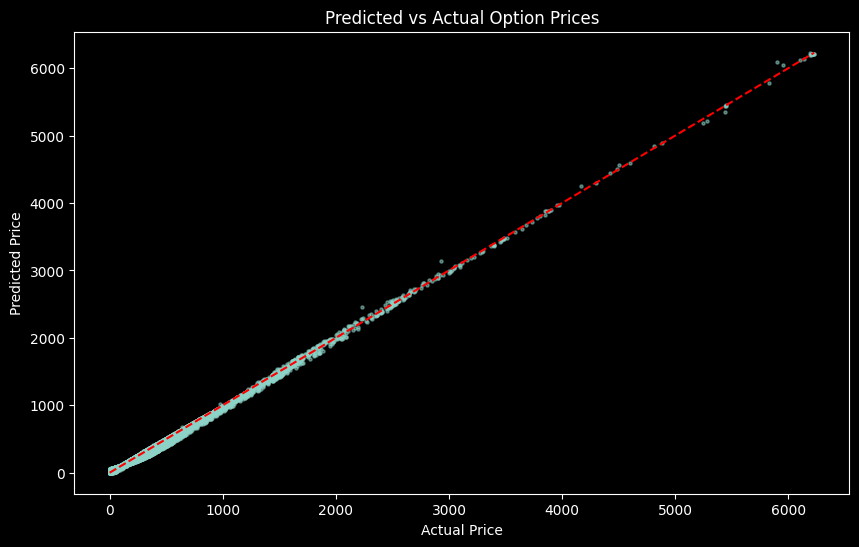

In [23]:
# Visualization
import matplotlib.pyplot as plt
import numpy as np

model.eval()
val_loader = data_module.val_dataloader()

all_preds = []
all_actuals = []


for idx, batch in enumerate(val_loader):
    x, y = batch
    mps_x = x.clone().to("mps")
    preds, _ = model(x.to("mps"))
    all_preds.append(preds.detach().cpu().numpy() * x[:, 1].numpy().reshape(-1, 1))
    all_actuals.append(y.numpy() * x[:, 1].numpy().reshape(-1, 1))

all_preds = np.concatenate(all_preds).flatten()
all_actuals = np.concatenate(all_actuals).flatten()

plt.figure(figsize=(10, 6))
plt.scatter(all_actuals, all_preds, s=5, alpha=0.5)
plt.plot([all_actuals.min(), all_actuals.max()], [all_actuals.min(), all_actuals.max()], 'r--')
plt.xlabel('Actual Price')
plt.ylabel('Predicted Price')
plt.title('Predicted vs Actual Option Prices')
plt.savefig('predicted_vs_actual.png')
print("Scatterplot saved to predicted_vs_actual.png")

Scatterplot saved to predicted_vs_actual.png


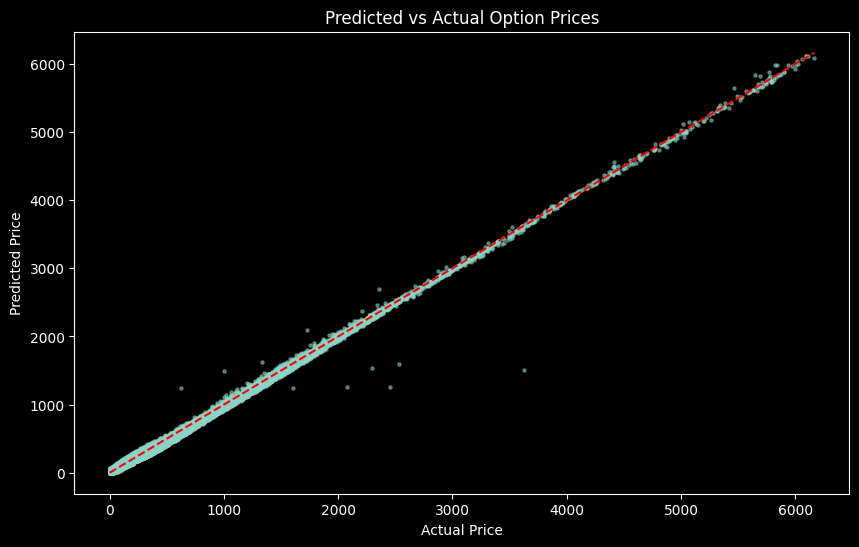

In [22]:
model.eval()
val_loader = data_module.train_dataloader()

all_preds = []
all_actuals = []


for batch in val_loader:
    x, y = batch
    mps_x = x.clone().to("mps")
    preds, _ = model(x.to("mps"))
    all_preds.append(preds.detach().cpu().numpy() * x[:, 1].numpy().reshape(-1, 1))
    all_actuals.append(y.numpy() * x[:, 1].numpy().reshape(-1, 1))


all_preds = np.concatenate(all_preds).flatten()
all_actuals = np.concatenate(all_actuals).flatten()

plt.figure(figsize=(10, 6))
plt.scatter(all_actuals, all_preds, s=5, alpha=0.5)
plt.plot([all_actuals.min(), all_actuals.max()], [all_actuals.min(), all_actuals.max()], 'r--')
plt.xlabel('Actual Price')
plt.ylabel('Predicted Price')
plt.title('Predicted vs Actual Option Prices')
plt.savefig('predicted_vs_actual.png')
print("Scatterplot saved to predicted_vs_actual.png")